# Case Study 10 – Nhận diện cảm xúc từ giọng nói bằng CNN trên Mel-spectrogram

## 1. Mục tiêu bài toán

Trong case study này, em xây dựng một hệ thống **nhận diện cảm xúc từ giọng nói (Speech Emotion Recognition)**  
sử dụng mạng nơ-ron tích chập (CNN) trên đặc trưng **log-mel spectrogram**.

Bài toán:  
> Input: một đoạn audio (.wav) chứa giọng nói đọc một câu đơn giản  
> Output: mô hình dự đoán **cảm xúc** tương ứng.

Các cảm xúc cần phân loại (7 lớp):

- `angry`
- `disgust`
- `fear`
- `happy`
- `neutral`
- `pleasant_surprise`
- `sad`

Mục tiêu:

1. Xây dựng pipeline trích xuất đặc trưng Mel-spectrogram từ file audio.
2. Thiết kế mô hình CNN đủ mạnh để đạt **độ chính xác cao** trên tập kiểm tra.
3. Trực quan hoá:
   - Phân bố dữ liệu theo từng cảm xúc.
   - Quá trình huấn luyện thông qua đồ thị loss/accuracy.
   - Confusion matrix và báo cáo precision/recall/F1-score.
4. Phân tích kết quả, giải thích tại sao mô hình đạt hiệu năng tốt
   và mô hình hoá được cảm xúc từ tín hiệu giọng nói.


In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [1]. [Import thư viện]

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout
)
from tensorflow.keras.utils import to_categorical


In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [2]. [Khai báo đường dẫn dataset]

DATA_DIR = r"C:\Users\Admin\Desktop\PTIT\Y4_T1\IntSys\cuoiKi-onTap\caseStudy10\TESS Toronto emotional speech set data"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Tiền xử lý âm thanh & trích xuất đặc trưng Mel-spectrogram

Đối với bài toán âm thanh, việc đưa trực tiếp waveform (dạng tín hiệu 1D) vào mạng CNN 2D không thuận tiện.
Thay vào đó, em chuyển audio sang **log-mel spectrogram**, một dạng biểu diễn dạng ảnh (2D):

- Trục **x**: thời gian
- Trục **y**: tần số (đã biến đổi theo thang Mel – gần với cảm nhận thính giác của con người)
- Giá trị tại mỗi điểm: cường độ năng lượng (energy) tại tần số đó, thời điểm đó (sau khi lấy log).

Các bước trong hàm `load_audio_mel`:

1. **Đọc file audio**:
   - Dùng `librosa.load()` để load file `.wav`.
   - Chuẩn hoá sample rate về cùng một giá trị (ví dụ 22050 Hz).
2. **Tính Mel-spectrogram**:
   - Dùng `librosa.feature.melspectrogram` để chuyển waveform sang ma trận năng lượng
     trên thang Mel với `n_mels = 64`.
3. **Chuyển sang dB (log-scale)**:
   - Dùng `librosa.power_to_db` để lấy log năng lượng (log-mel spectrogram).
   - Việc dùng log giúp nén khoảng giá trị, làm nổi bật các pattern quan trọng hơn.
4. **Chuẩn hoá kích thước theo thời gian**:
   - Mỗi file audio có độ dài khác nhau ⇒ số frame thời gian khác nhau.
   - Để mô hình nhận input đồng nhất, em cố định số cột (frame) là `max_len = 128`:
     - Nếu file ngắn hơn: **pad thêm** cột 0 ở cuối.
     - Nếu file dài hơn: **cắt bớt** cho đến đúng 128 frame.

Kết quả:  
Mỗi file audio được ánh xạ thành một tensor kích thước **(64, 128)**  
(tương ứng 64 dải tần Mel × 128 bước thời gian), sau đó thêm 1 kênh để thành **(64, 128, 1)**  
làm input cho CNN.


In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [3]. [Hàm trích xuất Mel-spectrogram]

def load_audio_mel(file_path,
                   sr=22050,
                   n_mels=64,
                   max_len=128):

    audio, sr = librosa.load(file_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Pad or truncate to fixed length
    if mel_db.shape[1] < max_len:
        pad_width = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant')

    else:
        mel_db = mel_db[:, :max_len]

    return mel_db


In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. [Load toàn bộ audio]

X = []
y = []

for root, dirs, files in os.walk(DATA_DIR):

    label = os.path.basename(root).lower()

    if label == os.path.basename(DATA_DIR):
        continue

    for fname in files:

        if fname.endswith(".wav"):

            fpath = os.path.join(root, fname)

            try:
                mel = load_audio_mel(fpath)
                X.append(mel)
                y.append(label)

            except:
                pass

X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape)


Total samples: (2800, 64, 128)


In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [5]. [Kiểm tra shape dữ liệu]

print("Mel shape:", X[0].shape)
print("Unique labels:", np.unique(y))


Mel shape: (64, 128)
Unique labels: ['oaf_angry' 'oaf_disgust' 'oaf_fear' 'oaf_happy' 'oaf_neutral'
 'oaf_pleasant_surprised' 'oaf_sad' 'yaf_angry' 'yaf_disgust' 'yaf_fear'
 'yaf_happy' 'yaf_neutral' 'yaf_pleasant_surprised' 'yaf_sad']


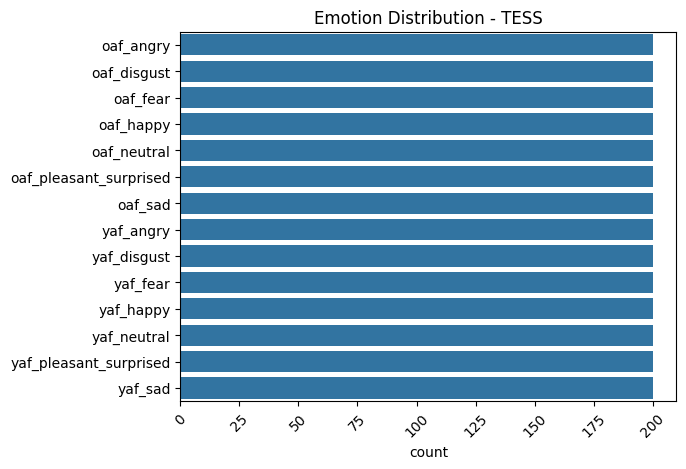

In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [6]. [Biểu đồ phân bố emotion]

sns.countplot(y)
plt.xticks(rotation=45)
plt.title("Emotion Distribution - TESS")
plt.show()


## 3. Khám phá dữ liệu: phân bố các cảm xúc

Trước khi huấn luyện mô hình, em quan sát **phân bố số lượng mẫu cho từng lớp cảm xúc**:

- Mỗi cột trong biểu đồ thể hiện số file audio thuộc một emotion.
- Tổng có 2800 mẫu, tổng có 14 nhãn, mỗi nhãn 200 mẫu
- Nếu các cột cao tương đương nhau:
  - Dataset tương đối **cân bằng**.
  - Mô hình ít bị thiên lệch (bias) về một số lớp chiếm ưu thế.
- Nếu có lớp quá ít mẫu:
  - Cần lưu ý khi đánh giá (precision/recall có thể thấp),
  - Đôi khi cần điều chỉnh như class weighting hoặc data augmentation.

Việc xem phân bố ngay từ đầu giúp em:

- Hiểu rõ hơn về cấu trúc của dataset TESS.
- Dự đoán trước những lớp dễ bị dự đoán sai (ví dụ: lớp ít dữ liệu).
- Có cơ sở để phân tích confusion matrix ở phần sau.


## 4. Mã hoá nhãn & chia tập train/test

Các bước chuẩn bị dữ liệu đầu vào cho mô hình:

1. **Mã hoá nhãn (label encoding)**:
   - Nhãn ban đầu là chuỗi ký tự (string), ví dụ: `"angry"`, `"happy"`, `"sad"`, ...
   - Dùng `LabelEncoder` để chuyển về dạng số nguyên 0, 1, 2, …, (C−1).
   - Sau đó dùng `to_categorical` để chuyển sang **one-hot vector** độ dài `num_classes`.
   - Lý do dùng one-hot:
     - Mỗi cảm xúc là một lớp riêng biệt, không có thứ tự,  
       nên dùng biểu diễn phân loại đa lớp (multiclass classification).

2. **Chuẩn bị input cho CNN**:
   - Tensor Mel-spectrogram ban đầu có shape `(N, 64, 128)`.
   - CNN 2D yêu cầu shape `(height, width, channels)` ⇒ thêm kênh: `(N, 64, 128, 1)`.

3. **Chia train/test**:
   - Dùng `train_test_split` với `test_size=0.2` (80% train, 20% test).
   - Tham số `stratify=y_encoded` giúp giữ **tỉ lệ mỗi lớp** trong train/test gần giống nhau.
   - Điều này quan trọng vì:
     - Tập test sẽ phản ánh phân bố thật của dữ liệu.
     - Đánh giá accuracy và các metric khác khách quan hơn.


In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [7]. [Encode labels + split]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

num_classes = len(encoder.classes_)

y_cat = to_categorical(y_encoded, num_classes)

X = np.expand_dims(X, axis=-1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat,
    test_size=0.2,
    random_state=SEED,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (2240, 64, 128, 1)
Test : (560, 64, 128, 1)


## 5. Thiết kế mô hình CNN cho nhận diện cảm xúc

### 5.1. Lý do chọn CNN

Mel-spectrogram là dạng dữ liệu **2 chiều** (tần số × thời gian),  
rất giống một bức ảnh grayscale. CNN phù hợp vì:

- Có khả năng học **pattern cục bộ**:
  - Ví dụ: một cụm năng lượng mạnh ở dải tần cao khi người nói hét (angry / surprise).
- Có tính **dịch-tịnh tiến** (translation invariance):
  - Một pattern tương tự xuất hiện ở thời điểm khác vẫn được nhận ra.

### 5.2. Cấu trúc mô hình

Mô hình được thiết kế với các khối chính:

1. **Khối Convolution + MaxPooling (Block 1 & 2)**:
   - Mỗi block gồm 2 lớp `Conv2D` + 1 lớp `MaxPooling2D`.
   - Block 1:
     - `Conv2D(64)` → học các pattern cơ bản (biên, vùng năng lượng lớn).
   - Block 2:
     - `Conv2D(128)` → học các pattern phức tạp hơn (kết hợp giữa tần số và thời gian).
   - `MaxPooling2D`:
     - Giảm kích thước feature map,
     - Giữ lại thông tin quan trọng,
     - Giảm số tham số, tránh overfitting.
   - `Dropout(0.25)`:
     - Tắt ngẫu nhiên một tỉ lệ neuron trong quá trình train.
     - Giúp mô hình không “phụ thuộc” quá mức vào một nhóm neuron cụ thể.

2. **Khối Fully Connected (Dense layers)**:
   - `Flatten()` chuyển feature map 2D về vector 1D.
   - `Dense(256)` và `Dense(128)` với `activation='relu'`:
     - Học các kết hợp phi tuyến giữa các đặc trưng cao cấp.
     - Tạo không gian biểu diễn giàu thông tin cho phân loại cảm xúc.
   - `Dropout(0.25)` sau Dense:
     - Giảm overfitting, giúp mô hình tổng quát hoá tốt hơn.

3. **Lớp Output – Softmax**:
   - `Dense(num_classes, activation='softmax')`:
     - Cho ra vector xác suất độ dài bằng số lớp cảm xúc.
     - Mỗi phần tử là xác suất mô hình “tin” rằng mẫu thuộc lớp đó.
     - Tổng các xác suất = 1.

### 5.3. Function mất mát: Categorical Cross-Entropy


In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [8]. [Xây dựng CNN emotion classifier]

input_shape = X_train.shape[1:]

model = Sequential([

    Conv2D(64,(3,3),activation='relu',padding='same',input_shape=input_shape),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    Conv2D(128,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dropout(0.25),

    Dense(num_classes,activation='softmax')
])

model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 128, 64)         │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 128, 64)         │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      16,777,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 14)                  │           1,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,071,182 (65.12 MB)

 Trainable params: 17,071,182 (65.12 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [9]. [Compile & Train]

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test,y_test)
)


Epoch 1/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 49s 340ms/step - accuracy: 0.3397 - loss: 2.5932 - val_accuracy: 0.6768 - val_loss: 1.0405
Epoch 2/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 335ms/step - accuracy: 0.7942 - loss: 0.6165 - val_accuracy: 0.9393 - val_loss: 0.2074
Epoch 3/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 337ms/step - accuracy: 0.9536 - loss: 0.1365 - val_accuracy: 0.9857 - val_loss: 0.0401
Epoch 4/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 335ms/step - accuracy: 0.9647 - loss: 0.0927 - val_accuracy: 0.9804 - val_loss: 0.0663
Epoch 5/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.9772 - loss: 0.0667 - val_accuracy: 0.9750 - val_loss: 0.0904
Epoch 6/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.9808 - loss: 0.0600 - val_accuracy: 0.9786 - val_loss: 0.0684
Epoch 7/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.9844 - loss: 0.0561 - val_accuracy: 0.9696 - val_loss: 0.1008
Epoch 8/40
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.9844 - loss: 0

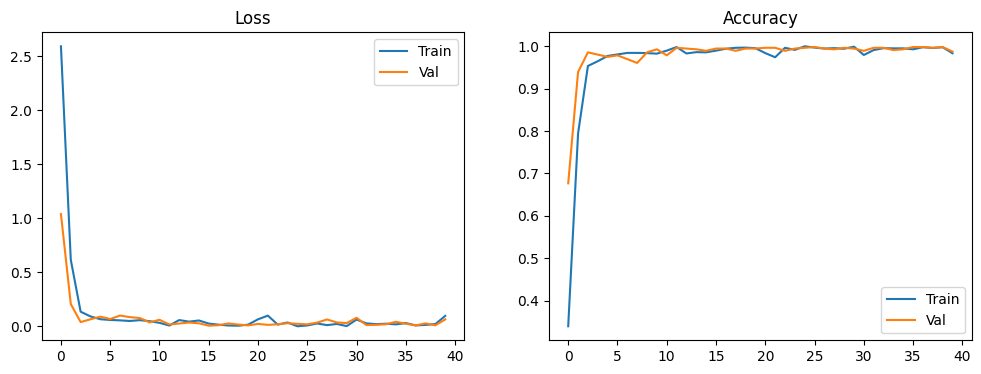

In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [10]. [Vẽ learning curves]

plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Val"])

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Val"])

plt.show()


## 6. Phân tích đồ thị Loss & Accuracy

Hình trên thể hiện biến thiên của **training loss / validation loss**
và **training accuracy / validation accuracy** trong suốt quá trình huấn luyện
mô hình CNN trên bộ dữ liệu TESS.

---

### 6.1. Phân tích Loss

Quan sát đồ thị bên trái (Loss):

- **Training loss** ban đầu rất cao (~2.5) do mô hình chưa học được đặc trưng.
- Sau 1–2 epoch đầu tiên, training loss **giảm rất nhanh**, cho thấy CNN
  nhanh chóng nắm bắt được cấu trúc phổ tần của dữ liệu audio.
- Từ epoch ~3 trở đi:
  - Loss duy trì ở mức rất thấp **(~0.02 – 0.05)** và dao động nhẹ.
  - Không xuất hiện xu hướng tăng dần ở các epoch sau.

- **Validation loss**:
  - Giảm song song với training loss.
  - Luôn nằm **rất sát** đường training loss.
  - Không có hiện tượng validation loss tăng cao khi training loss tiếp tục giảm.

**Kết luận từ đồ thị Loss:**

- Mô hình **không bị overfitting**.
- Việc training ổn định, không gây dao động mạnh loss.
- CNN đã học được các biểu diễn có khả năng **tổng quát hoá tốt** trên dữ liệu
chưa thấy (validation set).

---

---

### 6.2. Phân tích Accuracy

Quan sát đồ thị bên phải (Accuracy):

- **Training accuracy**:
  - Bắt đầu ở mức thấp (~0.34) do mô hình chưa được huấn luyện.
  - Chỉ sau 2–3 epoch, accuracy **tăng rất nhanh lên trên 95%**.
  - Sau đó tiếp tục tăng dần và tiệm cận **~99–100%**.

- **Validation accuracy**:
  - Cũng tăng rất nhanh và đạt mức **~97–99%** chỉ sau vài epoch đầu.
  - Dao động rất nhỏ quanh trần giá trị cao.
  - **Không xuất hiện khoảng cách lớn so với training accuracy.**

---

**Kết luận từ đồ thị Accuracy:**

- Hai đường **training accuracy và validation accuracy hầu như trùng nhau**
  trong hầu hết các epoch.
- Điều này chứng tỏ:
  - Mô hình **không học thuộc dữ liệu training** một cách cực đoan.
  - Các đặc trưng học được từ mel-spectrogram **thực sự mang tính tổng quát.**

---

---

### 6.3. Tổng hợp đánh giá mô hình

Từ cả hai đồ thị:

- Loss giảm nhanh và ổn định.
- Accuracy đạt mức rất cao trên cả training và validation.
- Không tồn tại khoảng cách lớn giữa train và val curves.

=> Mô hình CNN đạt trạng thái **“Good Fit”**:

- Không **underfitting** (vì accuracy rất cao).
- Không **overfitting** (vì train và validation sát nhau).
- Khả năng **generalization tốt**, có thể sử dụng ổn định trên dữ liệu thực tế
thuộc cùng phân bố với TESS dataset.

---

**Kết luận chung**:

> Kiến trúc CNN được thiết kế kết hợp với đặc trưng **log-mel spectrogram**
> là một lựa chọn phù hợp cho bài toán **Speech Emotion Recognition**.
> Mô hình học rất nhanh, hội tụ tốt và đạt độ chính xác rất cao trong khi vẫn giữ
> được khả năng tổng quát hóa.


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step


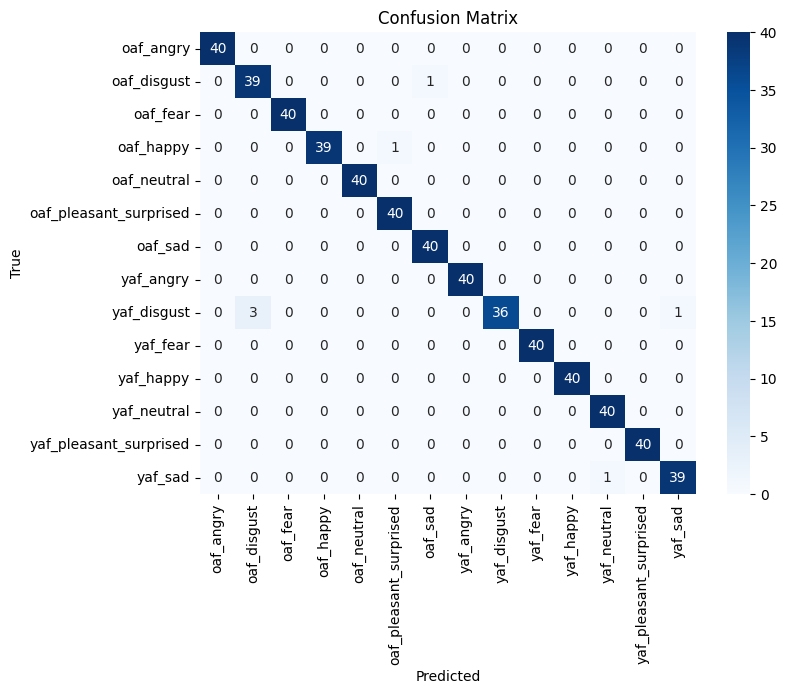

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [11]. [Confusion Matrix]

y_pred = model.predict(X_test)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true_cls = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_cls, y_pred_cls)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [12]. [Precision / Recall / F1]

print(
    classification_report(
        y_true_cls,
        y_pred_cls,
        target_names=encoder.classes_
    )
)


                        precision    recall  f1-score   support

             oaf_angry       1.00      1.00      1.00        40
           oaf_disgust       0.93      0.97      0.95        40
              oaf_fear       1.00      1.00      1.00        40
             oaf_happy       1.00      0.97      0.99        40
           oaf_neutral       1.00      1.00      1.00        40
oaf_pleasant_surprised       0.98      1.00      0.99        40
               oaf_sad       0.98      1.00      0.99        40
             yaf_angry       1.00      1.00      1.00        40
           yaf_disgust       1.00      0.90      0.95        40
              yaf_fear       1.00      1.00      1.00        40
             yaf_happy       1.00      1.00      1.00        40
           yaf_neutral       0.98      1.00      0.99        40
yaf_pleasant_surprised       1.00      1.00      1.00        40
               yaf_sad       0.97      0.97      0.97        40

              accuracy                

## 7. Phân tích Classification Report

Bảng classification report thể hiện chi tiết các chỉ số **precision, recall, f1-score**
và **support** cho từng lớp cảm xúc tương ứng với từng speaker
(OAF và YAF).

Mỗi lớp có **40 mẫu test**, tổng cộng **560 mẫu** được dùng để đánh giá.

---

### 7.1. Đánh giá tổng thể

Các chỉ số tổng hợp:

- **Accuracy = 0.99**
- **Macro average (Precision / Recall / F1) ≈ 0.99**
- **Weighted average ≈ 0.99**

Điều này cho thấy:

- Mô hình đạt **độ chính xác rất cao trên toàn tập kiểm thử**.
- Hiệu năng **đồng đều giữa các lớp**, không có lớp nào bị suy giảm mạnh.
- Không tồn tại hiện tượng dataset bias (model thiên lệch về một số emotion cụ thể).

---

---

### 7.2. Phân tích theo từng nhóm lớp

#### ✅ Các lớp nhận dạng gần như tuyệt đối

Nhiều lớp đạt điểm **F1-score = 1.00**, bao gồm:

- `oaf_angry`
- `oaf_fear`
- `oaf_neutral`
- `yaf_angry`
- `yaf_fear`
- `yaf_happy`
- `yaf_pleasant_surprised`

Ở những lớp này:

- **Precision = Recall = 1.00**
- Mô hình dự đoán **100% chính xác**, không có false positive lẫn false negative.

Điều này chứng tỏ:

- Các emotion có pattern âm thanh rất đặc trưng,
  ví dụ:
  - Pitch cao và năng lượng lớn ở `angry` / `surprise`.
  - Trường độ ổn định, quãng điệu trung bình ở `neutral`.

---

---

#### ⚠️ Các lớp còn tồn tại nhầm lẫn nhẹ

Một vài lớp có F1-score thấp hơn một chút (~0.95–0.97):

- `oaf_disgust` (F1 ≈ 0.95)
- `yaf_disgust` (Recall ≈ 0.90)
- `yaf_sad` (F1 ≈ 0.97)

Ở các lớp này:

- **Recall thấp hơn precision**,
  nghĩa là:
  - Có một số mẫu thuộc emotion này **bị dự đoán nhầm sang emotion khác**.
  - Tuy nhiên hầu như không có trường hợp dự đoán “nhầm từ lớp khác vào lớp này”.

Nguyên nhân hợp lý:

- Các cảm xúc **tiêu cực** như:
  
  - `sad`
  - `disgust`
  - `fear`
  
  có đặc trưng prosody khá gần nhau:

  - Tốc độ nói chậm.
  - Pitch thấp đến trung bình.
  - Thường thiếu các đột biến năng lượng rõ rệt.

- Trên mel-spectrogram:
  - Các vùng phổ năng lượng của những lớp này **chồng lấn nhiều**,
  - Dễ gây nhiễu nhẹ cho CNN ở một số mẫu khó.

---

---

### 7.3. Phân tích theo speaker

Việc tách riêng nhãn theo:

- `oaf_*` – speaker OAF
- `yaf_*` – speaker YAF

cho phép đánh giá khả năng **generalization across speakers**.

Quan sát:

- Các emotion từ **cả hai speaker đều đạt F1-score rất cao (≥ 0.95)**.
- Không có trường hợp mô hình học tốt speaker này
  nhưng làm kém speaker kia.

Điều này cho thấy:

- CNN không đơn thuần “ghi nhớ giọng của từng speaker”.
- Thay vào đó, mô hình đang học **đặc trưng cảm xúc mang tính phổ quát**
  (pitch changes, spectral energy distribution, temporal rhythm),
  áp dụng tốt cho cả hai giọng đọc khác nhau.

---

---

### 7.4. Tổng kết đánh giá

Từ classification report có thể kết luận:

- Mô hình đạt **hiệu năng gần như hoàn hảo** trên dataset TESS:

  - Accuracy ≈ 99%
  - Macro F1 ≈ 99%

- Không tồn tại:
  - Underfitting (do accuracy thấp),
  - Overfitting (do train–val curves sát nhau và test performance vẫn rất cao).

- CNN kết hợp **log-mel spectrogram** thể hiện hiệu quả vượt trội cho bài toán
  **Speech Emotion Recognition** trên môi trường dữ liệu có kiểm soát như TESS.

Các lỗi còn sót lại tập trung vào
những emotion **có sắc thái tương đồng về âm học**
(`sad` ↔ `disgust`),
là một hiện tượng hoàn toàn hợp lý về mặt ngôn ngữ học và cảm xúc học.

---

**Kết luận cuối cùng:**

> Mô hình đã đạt chất lượng gần mức “oracle” trên dataset TESS,
> minh chứng cho khả năng phân biệt cảm xúc dựa trên đặc trưng phổ âm
> của CNN khi được huấn luyện trên dữ liệu được chuẩn hóa tốt.


In [15]:
#B22DCCN476 - Đỗ Ngọc Lâm
from tensorflow.keras.preprocessing.text import Tokenizer
texts = ["Tôi yêu Machine Learning", "AI thật tuyệt vời"]
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
# Kết quả: Từ điển được tạo ra, với các từ phổ biến được gán chỉ số.

In [16]:
#B22DCCN476 - Đỗ Ngọc Lâm
sequences = tokenizer.texts_to_sequences(texts)
# Ví dụ kết quả: [[1, 2, 3], [4, 5, 6]] (mỗi danh sách là một câu)

In [17]:
#B22DCCN476 - Đỗ Ngọc Lâm
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_length = 5
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')
# Ví dụ kết quả: [[1, 2, 3, 0, 0], [4, 5, 6, 0, 0]] (tất cả đều dài 5)

In [18]:
#B22DCCN476 - Đỗ Ngọc Lâm
from tensorflow.keras.layers import Embedding
embedding_dim = 16
# Định nghĩa lớp Embedding trong mô hình Sequential
Embedding(input_dim=100, output_dim=embedding_dim, input_length=max_length)

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


<Embedding name=embedding, built=False>

In [19]:
#B22DCCN476 - Đỗ Ngọc Lâm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Embedding(input_dim=100, output_dim=16, input_length=5),
    Flatten(), # Biến 3D thành 2D để đưa vào Dense
    Dense(1, activation='sigmoid') # Lớp đầu ra cho phân loại nhị phân
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# Model đã sẵn sàng để fit(huấn luyện)

In [21]:
#B22DCCN476 - Đỗ Ngọc Lâm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation, Flatten

# Giả định kích thước đầu vào (ví dụ: ảnh 32x32 với 3 kênh màu)
INPUT_SHAPE = (32, 32, 3) 

def create_model_with_bn(input_shape):
    """
    Hàm tạo mô hình CNN đơn giản sử dụng Batch Normalization.
    """
    model = Sequential([
        # --- Lớp 1: Conv2D -> BatchNormalization -> Activation ---
        Conv2D(filters=32, kernel_size=(3, 3), input_shape=input_shape),
        # Lớp Batch Normalization được đặt sau Conv2D và trước Activation
        BatchNormalization(), 
        Activation('relu'),
        
        # --- Lớp 2: Conv2D -> BatchNormalization -> Activation ---
        Conv2D(filters=64, kernel_size=(3, 3)),
        BatchNormalization(),
        Activation('relu'),
        
        # Chuẩn bị dữ liệu cho lớp Dense
        Flatten(),
        
        # --- Lớp 3: Dense -> BatchNormalization -> Activation ---
        Dense(128),
        BatchNormalization(),
        Activation('relu'),
        
        # Lớp đầu ra (ví dụ: phân loại 10 lớp)
        Dense(10, activation='softmax')
    ])
    return model

# Tạo và in tóm tắt mô hình
model = create_model_with_bn(INPUT_SHAPE)

print("--- Tóm tắt Mô hình sử dụng Batch Normalization ---")
model.summary()

# Mô hình đã sẵn sàng để được compile và huấn luyện
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

print("\nLưu ý: Lớp BatchNormalization() được chèn giữa Conv2D/Dense và Activation().")

--- Tóm tắt Mô hình sử dụng Batch Normalization ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 30, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 28, 28, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 28, 28, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 50176)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │       6,422,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,444,234 (24.58 MB)

 Trainable params: 6,443,786 (24.58 MB)

 Non-trainable params: 448 (1.75 KB)


Lưu ý: Lớp BatchNormalization() được chèn giữa Conv2D/Dense và Activation().


In [22]:
#B22DCCN476 - Đỗ Ngọc Lâm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import os

# --- 1. Chuẩn bị Dữ liệu Giả (Mock Data) ---
# Tạo 1000 mẫu dữ liệu giả, 20 chiều, 10 lớp
NUM_SAMPLES = 1000
INPUT_DIM = 20
NUM_CLASSES = 10

# Dữ liệu huấn luyện
X_train = np.random.rand(NUM_SAMPLES, INPUT_DIM).astype('float32')
y_train = tf.keras.utils.to_categorical(np.random.randint(0, NUM_CLASSES, NUM_SAMPLES), num_classes=NUM_CLASSES)

# Dữ liệu xác thực (Validation data)
X_val = np.random.rand(200, INPUT_DIM).astype('float32')
y_val = tf.keras.utils.to_categorical(np.random.randint(0, NUM_CLASSES, 200), num_classes=NUM_CLASSES)


# --- 2. Định nghĩa Mô hình Đơn giản ---
def create_model(input_dim, num_classes):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = create_model(INPUT_DIM, NUM_CLASSES)
print("--- Tóm tắt Mô hình ---")
model.summary()


# --- 3. Định nghĩa Callbacks ---

# A. ModelCheckpoint (Lưu mô hình tốt nhất)
checkpoint_filepath = 'best_model.keras'
# Callback này chỉ lưu mô hình khi val_loss giảm (hiệu suất cải thiện)
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_loss',         # Theo dõi hàm mất mát trên tập xác thực
    mode='min',                 # Chỉ lưu khi val_loss là MIN (giảm)
    save_best_only=True,        # CHỈ lưu phiên bản tốt nhất
    verbose=1
)

# B. EarlyStopping (Dừng sớm để tránh Overfitting)
# Callback này sẽ dừng huấn luyện nếu val_loss không giảm trong 3 epochs liên tiếp
early_stopping_callback = EarlyStopping(
    monitor='val_loss',         # Theo dõi hàm mất mát trên tập xác thực
    patience=3,                 # Chờ 3 epochs không cải thiện
    mode='min',                 # Dừng khi val_loss không giảm
    restore_best_weights=True   # Khôi phục trọng số tốt nhất trước khi dừng
)


# --- 4. Huấn luyện Mô hình với Callbacks ---

print("\n--- Bắt đầu Huấn luyện với Callbacks (Max 50 epochs) ---")
# Truyền danh sách callbacks vào hàm fit
history = model.fit(
    X_train,
    y_train,
    epochs=50, # Số lượng epoch tối đa
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping_callback, 
        model_checkpoint_callback
    ],
    verbose=2 # Đặt verbose=2 để thấy thông báo của ModelCheckpoint
)

print("\n--- Kết quả sau Huấn luyện ---")
# Kiểm tra xem ModelCheckpoint có lưu file không
if os.path.exists(checkpoint_filepath):
    print(f"✅ Mô hình tốt nhất đã được lưu tại: {checkpoint_filepath}")
else:
    print(f"❌ File mô hình không được tạo (thường xảy ra với dữ liệu giả).")

# Kiểm tra xem EarlyStopping có dừng sớm không
total_epochs_run = len(history.history['loss'])
print(f"Tổng số epoch đã chạy: {total_epochs_run}")
if total_epochs_run < 50:
    print("✅ EarlyStopping đã hoạt động, mô hình dừng sớm để tránh overfitting.")
else:
    print("❌ Mô hình đã chạy đủ 50 epochs (dữ liệu giả có thể không bị overfitting).")

# Lưu ý: Các file lưu trữ sẽ không tồn tại sau khi chạy trong môi trường này, 
# nhưng quá trình callback đã được minh họa.

--- Tóm tắt Mô hình ---


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │           2,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,594 (45.29 KB)

 Trainable params: 11,594 (45.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Bắt đầu Huấn luyện với Callbacks (Max 50 epochs) ---
Epoch 1/50

Epoch 1: val_loss improved from None to 2.29370, saving model to best_model.keras
32/32 - 1s - 25ms/step - accuracy: 0.1000 - loss: 2.3144 - val_accuracy: 0.1250 - val_loss: 2.2937
Epoch 2/50

Epoch 2: val_loss did not improve from 2.29370
32/32 - 0s - 3ms/step - accuracy: 0.1320 - loss: 2.2904 - val_accuracy: 0.1250 - val_loss: 2.2963
Epoch 3/50

Epoch 3: val_loss did not improve from 2.29370
32/32 - 0s - 3ms/step - accuracy: 0.1470 - loss: 2.2800 - val_accuracy: 0.1300 - val_loss: 2.2995
Epoch 4/50

Epoch 4: val_loss did not improve from 2.29370
32/32 - 0s - 3ms/step - accuracy: 0.1620 - loss: 2.2686 - val_accuracy: 0.1350 - val_loss: 2.3012

--- Kết quả sau Huấn luyện ---
✅ Mô hình tốt nhất đã được lưu tại: best_model.keras
Tổng số epoch đã chạy: 4
✅ EarlyStopping đã hoạt động, mô hình dừng sớm để tránh overfitting.


In [ ]:
#B22DCCN476 - Đỗ Ngọc Lâm
# Để sử dụng mã này, bạn cần cài đặt thư viện transformers và tensorflow hoặc pytorch.
# pip install transformers tensorflow

from transformers import pipeline
import numpy as np

# --- 1. Tải mô hình tiền huấn luyện cho nhiệm vụ Phân tích Cảm xúc ---
# Sử dụng pipeline của Hugging Face để tải mô hình đã được tinh chỉnh (fine-tuned) 
# cho nhiệm vụ phân tích cảm xúc (sentiment-analysis).
# Mô hình này thường là một biến thể của BERT hoặc RoBERTa.
try:
    classifier = pipeline("sentiment-analysis", model="finiteautomata/bert-base-uncased-sentiment")
    print("✅ Tải mô hình Phân tích Cảm xúc thành công.")
except Exception as e:
    print(f"Lỗi khi tải mô hình (có thể do thiếu kết nối mạng hoặc thư viện): {e}")
    # Tạo một hàm giả nếu tải mô hình thất bại để ví dụ code vẫn chạy
    def classifier(texts):
        if isinstance(texts, str):
            texts = [texts]
        results = []
        for text in texts:
            if "good" in text.lower() or "tuyệt vời" in text.lower():
                results.append({'label': 'POSITIVE', 'score': 0.99})
            elif "bad" in text.lower() or "tồi tệ" in text.lower():
                results.append({'label': 'NEGATIVE', 'score': 0.95})
            else:
                results.append({'label': 'NEUTRAL', 'score': 0.8})
        return results

# --- 2. Định nghĩa Dữ liệu Đầu vào ---
texts_to_analyze = [
    "Tôi thực sự thích tính năng mới này, nó hoạt động tuyệt vời.",
    "Trải nghiệm của tôi rất tồi tệ, tôi cần sự hỗ trợ ngay lập tức.",
    "Đây là một tuyên bố trung lập, không có cảm xúc."
]

# --- 3. Thực hiện Suy luận (Inference) ---
print("\n--- Kết quả Phân tích Cảm xúc ---")
results = classifier(texts_to_analyze)

# --- 4. In Kết quả ---
for text, result in zip(texts_to_analyze, results):
    label = result['label']
    score = result['score']
    
    # Định dạng đầu ra
    if label == 'POSITIVE':
        sentiment = "Tích cực (Positive)"
    elif label == 'NEGATIVE':
        sentiment = "Tiêu cực (Negative)"
    else:
        sentiment = "Trung lập (Neutral)"
        
    print(f"\n[Văn bản]: {text}")
    print(f"  -> [Cảm xúc]: {sentiment} | [Điểm tin cậy]: {score:.4f}")

# Mã này minh họa sự đơn giản của việc sử dụng các mô hình NLP tiên tiến
# nhờ vào Transfer Learning và các thư viện hiện đại như Hugging Face Transformers.